This project analyzes mobile user behavior to identify usage patterns, engagement levels, and potential user segments. The goal is to derive actionable insights and build a foundation for a behavioral analytics dashboard.


In [2]:
import pandas as pd

df = pd.read_excel("user_behavior_dataset.xlsx")
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [5]:
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [6]:
df.isnull().sum()

,0
User ID,0
Device Model,0
Operating System,0
App Usage Time (min/day),0
Screen On Time (hours/day),0
Battery Drain (mAh/day),0
Number of Apps Installed,0
Data Usage (MB/day),0
Age,0
Gender,0


In [13]:

df.drop_duplicates(inplace=True)

In [15]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns)

Index(['User_ID', 'Device_Model', 'Operating_System',
       'App_Usage_Time_(min/day)', 'Screen_On_Time_(hours/day)',
       'Battery_Drain_(mAh/day)', 'Number_of_Apps_Installed',
       'Data_Usage_(MB/day)', 'Age', 'Gender', 'User_Behavior_Class'],
      dtype='object')


In [16]:
df.head()

,User_ID,Device_Model,Operating_System,App_Usage_Time_(min/day),Screen_On_Time_(hours/day),Battery_Drain_(mAh/day),Number_of_Apps_Installed,Data_Usage_(MB/day),Age,Gender,User_Behavior_Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [18]:
# Engagement Score (custom metric)
df['Engagement_Score'] = (
    df['App_Usage_Time_(min/day)'] * 0.4 +
    df['Screen_On_Time_(hours/day)'] * 0.3 +
    df['Data_Usage_(MB/day)'] * 0.3
)

# User Segmentation
df['User_Type'] = df['Screen_On_Time_(hours/day)'].apply(
    lambda x: 'Low' if x < 3 else 'Medium' if x < 6 else 'High'
)

df.head()

,User_ID,Device_Model,Operating_System,App_Usage_Time_(min/day),Screen_On_Time_(hours/day),Battery_Drain_(mAh/day),Number_of_Apps_Installed,Data_Usage_(MB/day),Age,Gender,User_Behavior_Class,Engagement_Score,User_Type
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,495.72,High
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,391.81,Medium
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,159.40,Medium
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,358.34,Medium
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,372.49,Medium


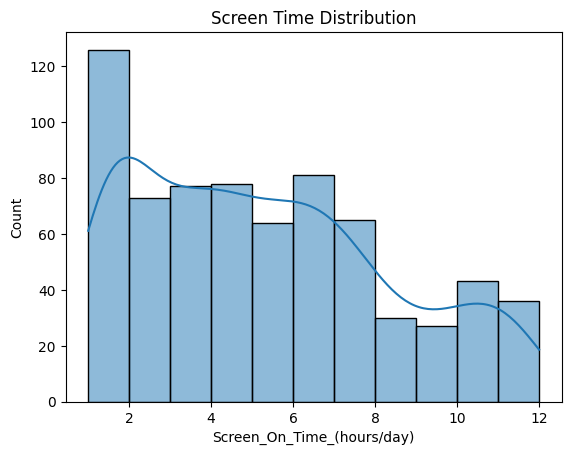

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Screen_On_Time_(hours/day)'], kde=True)
plt.title("Screen Time Distribution")
plt.show()

### Screen Time Distribution - Insight

The distribution of screen-on time shows how user activity is spread across the dataset. Most users fall into moderate usage levels, while a smaller group of users shows very high screen time, indicating heavy usage behavior

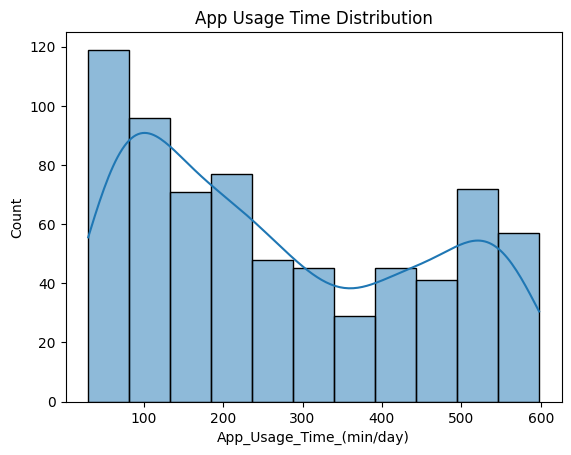

In [24]:
sns.histplot(df['App_Usage_Time_(min/day)'], kde=True)
plt.title("App Usage Time Distribution")
plt.show()

### App Usage Time Distribution - Insight

App usage time follows a similar pattern, where most users spend a moderate amount of time on apps. A few users exhibit significantly higher usage, representing highly engaged users.

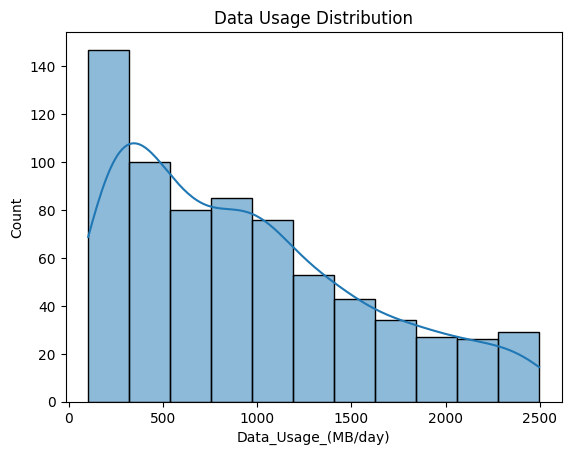

In [25]:
sns.histplot(df['Data_Usage_(MB/day)'], kde=True)
plt.title("Data Usage Distribution")
plt.show()

### Data Usage Distribution - Insight

Data usage varies across users, with a noticeable concentration in mid-range values. Higher data usage is typically associated with more active users consuming online content.

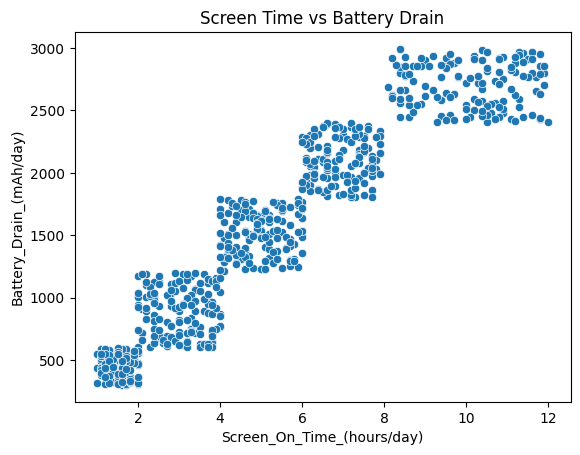

In [26]:
sns.scatterplot(
    x='Screen_On_Time_(hours/day)',
    y='Battery_Drain_(mAh/day)',
    data=df
)
plt.title("Screen Time vs Battery Drain")
plt.show()

### Screen Time vs Battery Drain - Insight

There is a strong positive relationship between screen-on time and battery drain. Users who spend more time on their devices tend to consume more battery, indicating that usage intensity directly impacts device performance.

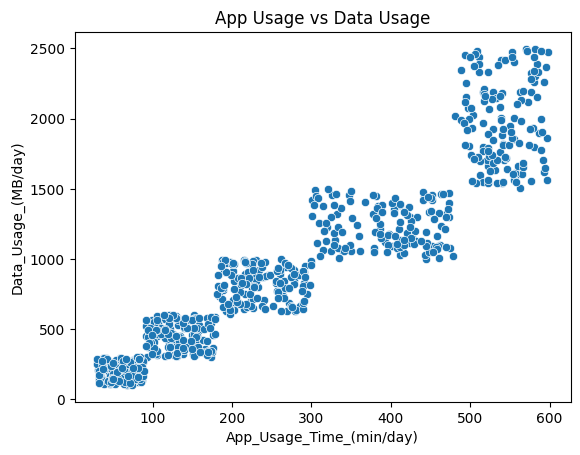

In [29]:
sns.scatterplot(
    x='App_Usage_Time_(min/day)',
    y='Data_Usage_(MB/day)',
    data=df
)
plt.title("App Usage vs Data Usage")
plt.show()

### App Usage vs Data Usage Insight:
App usage time shows a positive correlation with data consumption. Users who spend more time on applications tend to use more mobile data, suggesting that highly engaged users rely heavily on internet-based services.

In [27]:
df.groupby('Gender')['Screen_On_Time_(hours/day)'].mean()

,Screen_On_Time_(hours/day)
Gender,
Female,5.261310
Male,5.283242


### Gender Insight:
There are minor variations in screen-on time between genders, although overall usage patterns remain relatively similar. This suggests that gender may have a limited influence on mobile usage behavior.

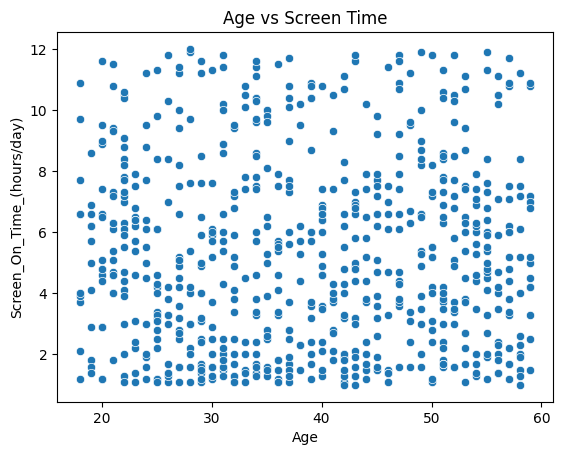

In [31]:
sns.scatterplot(x='Age', y='Screen_On_Time_(hours/day)', data=df)
plt.title("Age vs Screen Time")
plt.show()

### Age vs Screen Time Insight:
The relationship between age and screen-on time suggests that younger users tend to have higher device usage compared to older users, indicating stronger digital engagement among younger demographics.

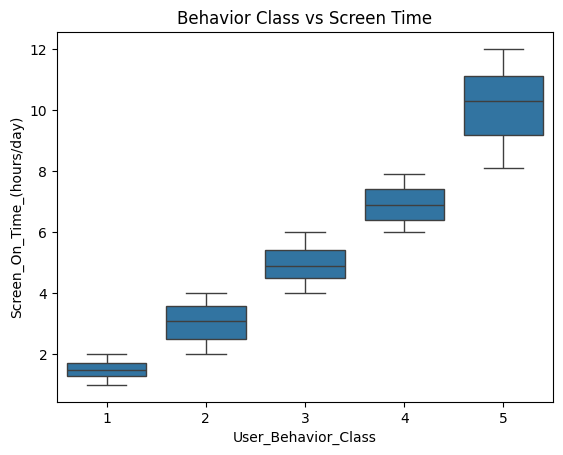

In [33]:
sns.boxplot(
    x='User_Behavior_Class',
    y='Screen_On_Time_(hours/day)',
    data=df
)
plt.title("Behavior Class vs Screen Time")
plt.show()

### Behavior Class vs Screen Time Insight:
Users in higher behavior classes exhibit greater screen-on time compared to lower classes. This confirms that the behavior classification effectively represents varying levels of user engagement.

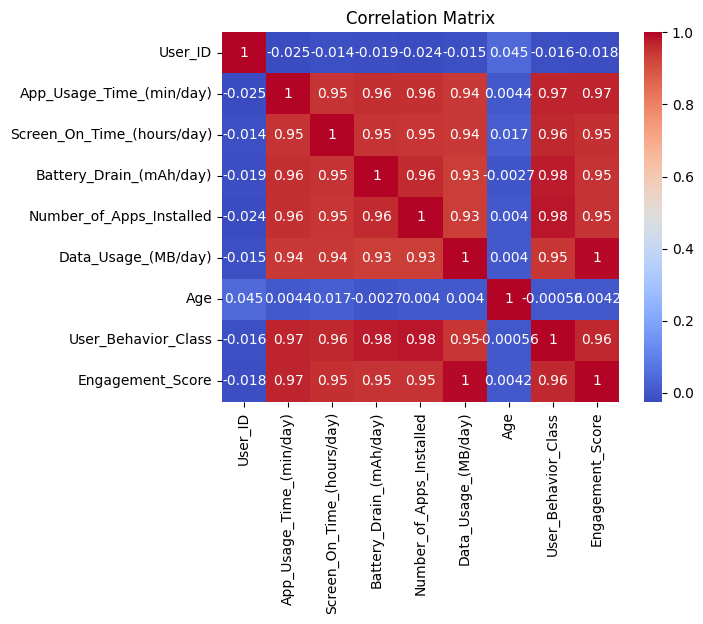

In [34]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix Insight:
The correlation analysis reveals strong relationships between key variables such as screen time, app usage, and battery drain. These factors are closely linked and collectively define overall user engagement patterns.

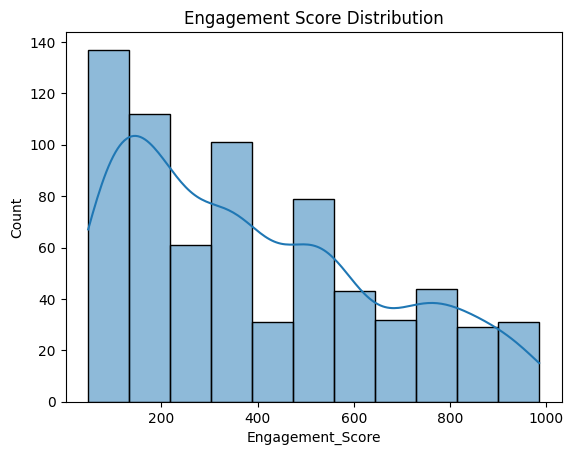

In [38]:
sns.histplot(df['Engagement_Score'], kde=True)
plt.title("Engagement Score Distribution")
plt.show()

### Engagement Score Distribution Insight:
The distribution of engagement scores highlights varying levels of user activity across the dataset. Most users fall within a moderate engagement range, while a smaller segment shows very high engagement, representing highly active users.

In [40]:
df.to_csv("cleaned_user_behavior.xlsx", index=False)